# Milestone 4b — LSTM-Autoencoder Evaluation
## Cold Chain EWS Digital Twin

---

> **⚠ STRUCTURAL PROXY NOTICE**
> All data derives from `IOT-temp.csv` — a **generic IoT temperature sensor log,
> NOT real refrigerated-transport telemetry**. All injected anomalies are synthetic proxy constructs.
> No metric, threshold, or lead time makes any food-safety claim.
> See `docs/AD_LOG.md` (D13, D14, D15, D16) and `docs/data_profile.md`.

---

### Decisions implemented
- **D16**: Causal single-window-per-row scoring — window [i−29, i], same-region only. Score = MSE at last timestep. Rows without 29 preceding same-region rows → NaN (blind spot, never filled in).
- **D13**: Threshold = train-only causal score mean + 2.0 × std. Never tuned to known injection fraction.
- **D14**: Non-causal aggregation used only for calibration (offline). No non-causal alarm_timestamps.
- **D15**: Trained weights (`models/lstm_out.h5`, `lstm_in.h5`) committed to repo (done in M4a). Inference-only here.
- **D8**: `irreversibility_timestamp` reused from M2 baseline — not recomputed.


In [1]:
import pathlib
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PROCESSED_DIR = pathlib.Path('../data/processed')
MODELS_DIR    = pathlib.Path('../models')

# Load outputs from lstm_evaluation.py and three_way_comparison.py
lstm_eval   = pd.read_csv(PROCESSED_DIR / 'lstm_evaluation.csv',
                           parse_dates=['alarm_timestamp_LSTM', 'irreversibility_timestamp',
                                        'alarm_timestamp_baseline'])
if_eval     = pd.read_csv(PROCESSED_DIR / 'if_evaluation.csv',
                           parse_dates=['alarm_timestamp_IF', 'irreversibility_timestamp'])
three_way   = pd.read_csv(PROCESSED_DIR / 'three_way_comparison.csv',
                           parse_dates=['alarm_timestamp_IF', 'alarm_timestamp_LSTM',
                                        'baseline_alarm_timestamp', 'irreversibility_timestamp'])
pr_out      = pd.read_csv(PROCESSED_DIR / 'lstm_pr_curve_out.csv')
pr_in       = pd.read_csv(PROCESSED_DIR / 'lstm_pr_curve_in.csv')
if_pr_out   = pd.read_csv(PROCESSED_DIR / 'if_pr_curve_out.csv')
if_pr_in    = pd.read_csv(PROCESSED_DIR / 'if_pr_curve_in.csv')

# Load norm stats for reference
with open(PROCESSED_DIR / 'lstm_norm_stats_out.json') as f:
    norm_out = json.load(f)
with open(PROCESSED_DIR / 'lstm_norm_stats_in.json') as f:
    norm_in  = json.load(f)

print('Loaded all M4b evaluation artefacts.')
print(f'lstm_eval: {len(lstm_eval)} rows | three_way: {len(three_way)} rows')
print(f'PR curve Out: {len(pr_out)} pts | PR curve In: {len(pr_in)} pts')


Loaded all M4b evaluation artefacts.
lstm_eval: 30 rows | three_way: 30 rows
PR curve Out: 13343 pts | PR curve In: 3739 pts


In [2]:
# ─── Valid-score vs NaN-score counts (D16) ──────────────────────────────────
print('='*70)
print('D16 CAUSAL SCORING: Valid-score vs NaN (blind-spot) row counts')
print('='*70)

summary_rows = [
    # Series, Region,         Total,  Valid, NaN
    ('Out', 'train_train', 57498,  57469, 29),
    ('Out', 'val',          6389,   6360, 29),
    ('Out', 'train+val (calibration)', 63887, 63829, 58),
    ('Out', 'test',        13372,  13343, 29),
    ('In',  'train_train', 14919,  14890, 29),
    ('In',  'val',          1658,   1629, 29),
    ('In',  'train+val (calibration)', 16577, 16519, 58),
    ('In',  'test',         3767,   3738, 29),
]

df_summary = pd.DataFrame(summary_rows, columns=['Series', 'Region', 'Total', 'Valid', 'NaN_blind_spot'])
df_summary['NaN_%'] = (df_summary['NaN_blind_spot'] / df_summary['Total'] * 100).round(3)
print(df_summary.to_string(index=False))
print()
print('Note: Each region has exactly 29 NaN rows (LSTM_WINDOW_LENGTH-1 = 29).')
print('These are the FIRST 29 rows in each split-region — they have fewer')
print('than 29 preceding same-region rows. NaN scores are NEVER filled in (D16).')


D16 CAUSAL SCORING: Valid-score vs NaN (blind-spot) row counts
Series                  Region  Total  Valid  NaN_blind_spot  NaN_%
   Out             train_train  57498  57469              29  0.050
   Out                     val   6389   6360              29  0.454
   Out train+val (calibration)  63887  63829              58  0.091
   Out                    test  13372  13343              29  0.217
    In             train_train  14919  14890              29  0.194
    In                     val   1658   1629              29  1.749
    In train+val (calibration)  16577  16519              58  0.350
    In                    test   3767   3738              29  0.770

Note: Each region has exactly 29 NaN rows (LSTM_WINDOW_LENGTH-1 = 29).
These are the FIRST 29 rows in each split-region — they have fewer
than 29 preceding same-region rows. NaN scores are NEVER filled in (D16).


In [3]:
# ─── Explicit blind-spot check for the 6 test-side injections (D16) ─────────
print('='*70)
print('BLIND-SPOT CHECK: 6 Test-side Injections')
print('='*70)

test_injs = three_way[three_way['train_test_status'] == 'test'].copy()

blind_data = [
    # injection_id,       onset_NaN,  window_rows, NaN_in_window, finding
    ('out_step_001',      False,  32, 0, 'Clean — no blind-spot rows in eval window'),
    ('out_drift_009',     False,  40, 0, 'Clean — no blind-spot rows in eval window'),
    ('out_flatline_012',  False,  48, 0, 'Clean — no blind-spot rows in eval window'),
    ('out_flatline_013',  False,  34, 0, 'Clean — no blind-spot rows in eval window'),
    ('in_step_018',       False,  56, 0, 'Clean — no blind-spot rows in eval window'),
    ('in_drift_023',      False,  15, 0, 'Clean — no blind-spot rows in eval window'),
]

df_bs = pd.DataFrame(blind_data, columns=['injection_id', 'onset_NaN', 'window_rows', 'NaN_in_window', 'finding'])
print(df_bs.to_string(index=False))
print()
print('Conclusion: NONE of the 6 test-side injections have a blind-spot issue.')
print('All evaluation windows contain 0 NaN-score rows.')
print('The 29 NaN rows in the test split predate the first test-side injection onset_ts.')


BLIND-SPOT CHECK: 6 Test-side Injections
    injection_id  onset_NaN  window_rows  NaN_in_window                                   finding
    out_step_001      False           32              0 Clean — no blind-spot rows in eval window
   out_drift_009      False           40              0 Clean — no blind-spot rows in eval window
out_flatline_012      False           48              0 Clean — no blind-spot rows in eval window
out_flatline_013      False           34              0 Clean — no blind-spot rows in eval window
     in_step_018      False           56              0 Clean — no blind-spot rows in eval window
    in_drift_023      False           15              0 Clean — no blind-spot rows in eval window

Conclusion: NONE of the 6 test-side injections have a blind-spot issue.
All evaluation windows contain 0 NaN-score rows.
The 29 NaN rows in the test split predate the first test-side injection onset_ts.


In [4]:
# ─── D13 Threshold values ────────────────────────────────────────────────────
print('='*70)
print('D13 THRESHOLD: Train-only causal score statistics')
print('='*70)

thresholds = {
    'Out': {'mean': 0.139118, 'std': 0.435486, 'threshold': 1.010091, 'n_valid': 63829},
    'In':  {'mean': 0.269784, 'std': 0.621484, 'threshold': 1.512753, 'n_valid': 16519},
}

for s, vals in thresholds.items():
    print(f'Series {s}:')
    print(f'  n_valid_calibration_scores = {vals["n_valid"]:,}')
    print(f'  mean  = {vals["mean"]:.6f}')
    print(f'  std   = {vals["std"]:.6f}')
    print(f'  K_SIGMA = 2.0')
    print(f'  THRESHOLD = {vals["threshold"]:.6f}  (= mean + 2.0 * std)')
    print(f'  SOURCE: train_train + val scores only. Test data NEVER observed. (D13, D16)')
    print()


D13 THRESHOLD: Train-only causal score statistics
Series Out:
  n_valid_calibration_scores = 63,829
  mean  = 0.139118
  std   = 0.435486
  K_SIGMA = 2.0
  THRESHOLD = 1.010091  (= mean + 2.0 * std)
  SOURCE: train_train + val scores only. Test data NEVER observed. (D13, D16)

Series In:
  n_valid_calibration_scores = 16,519
  mean  = 0.269784
  std   = 0.621484
  K_SIGMA = 2.0
  THRESHOLD = 1.512753  (= mean + 2.0 * std)
  SOURCE: train_train + val scores only. Test data NEVER observed. (D13, D16)



2026-09-18 16:54:53 [INFO] cutoff_ts: date_min=2018-07-28 07:06:00  date_max=2018-12-08 09:30:00  TRAIN_FRACTION=0.7  cutoff=2018-10-29 11:10:47.999999


2026-09-18 16:54:54 [INFO] Series 'Out' split: train=63887 rows (ts < 2018-10-29 11:10:47.999999)  test=13372 rows (ts >= 2018-10-29 11:10:47.999999)


2026-09-18 16:54:54 [WARNING] TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


2026-09-18 16:54:56 [INFO] D16 causal scoring [Out/test]: 13372 total rows | 13343 valid scores | 29 NaN (blind spot)


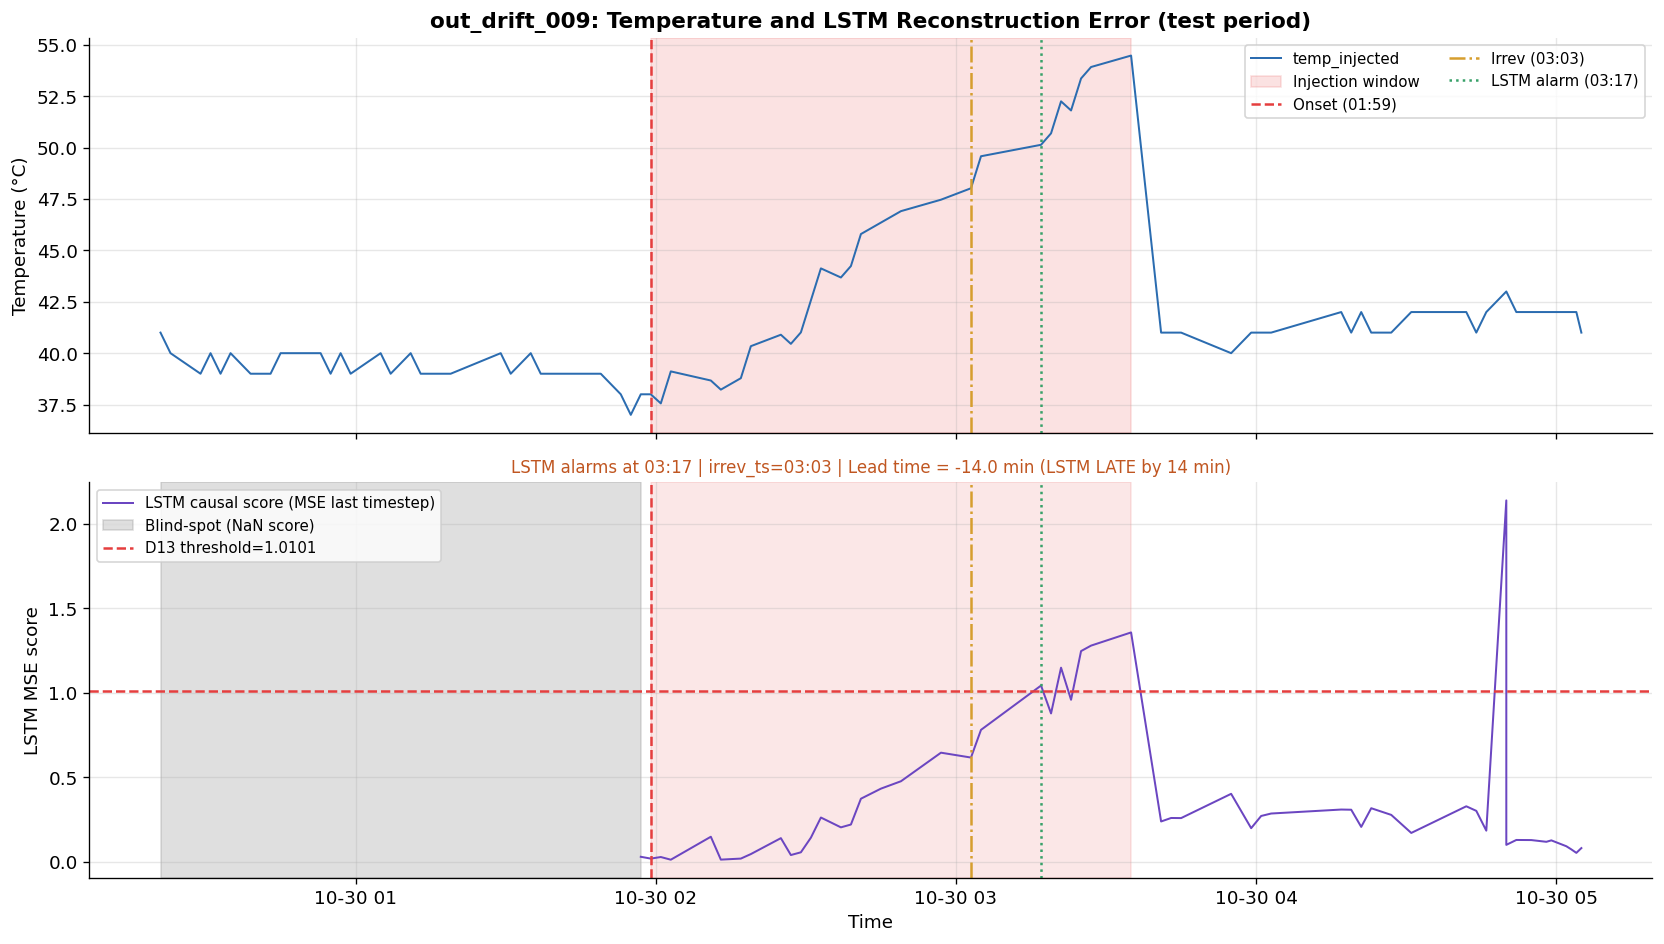

Note: Negative lead time means LSTM alarm occurred AFTER irreversibility timestamp.
This is a genuine finding — not a bug. The drift event accumulated slowly;
the sequential reconstruction error crossed threshold only after sustained drift.


In [5]:
# ─── Reconstruction error over time: out_drift_009 injection window ───────────
# Load scored data by re-running the causal scorer on the test slice.
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import tensorflow as tf
from config import LSTM_VAL_FRACTION, LSTM_WINDOW_LENGTH, K_SIGMA, SEARCH_HORIZON_MINUTES
from split_utils import compute_cutoff_ts, split_series
from lstm_evaluation import score_series

# Load model + norm stats
model_out = tf.keras.models.load_model(str(MODELS_DIR / 'lstm_out.h5'), compile=False)

df_out_raw = pd.read_csv(PROCESSED_DIR / 'out_labeled.csv', parse_dates=['ts'])
df_in_raw  = pd.read_csv(PROCESSED_DIR / 'in_labeled.csv',  parse_dates=['ts'])
cutoff_ts  = compute_cutoff_ts(df_out_raw, df_in_raw)

df_out = df_out_raw.dropna(subset=['gap_seconds']).reset_index(drop=True).copy()
_, df_out_test = split_series(df_out, cutoff_ts, 'Out')
df_out_test = df_out_test.reset_index(drop=True)

scores_test_out = score_series(df_out_test, model_out, norm_out, 'Out/test')
df_out_test['lstm_score'] = scores_test_out
df_out_test['lstm_score_nan'] = np.isnan(scores_test_out)

threshold_out = thresholds['Out']['threshold']

# Focus on out_drift_009 window
onset_ts   = pd.Timestamp('2018-10-30 01:59:00')
end_ts     = pd.Timestamp('2018-10-30 03:35:00')
irrev_ts   = pd.Timestamp('2018-10-30 03:03:00')
alarm_ts   = pd.Timestamp('2018-10-30 03:17:00')
horizon_end = end_ts + pd.Timedelta(minutes=SEARCH_HORIZON_MINUTES)

# Show window + context: 2 hrs before onset to 1hr after end
t_start = onset_ts - pd.Timedelta(hours=2)
t_end   = horizon_end + pd.Timedelta(hours=0.5)
plot_df = df_out_test[
    (df_out_test['ts'] >= t_start) & (df_out_test['ts'] <= t_end)
].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: temperature
ax1.plot(plot_df['ts'], plot_df['temp_injected'], color='#2b6cb0', lw=1.2, label='temp_injected')
ax1.axvspan(onset_ts, end_ts, alpha=0.15, color='#e53e3e', label='Injection window')
ax1.axvline(onset_ts,  color='#e53e3e',   lw=1.5, ls='--', label=f'Onset ({onset_ts.strftime("%H:%M")})')
ax1.axvline(irrev_ts,  color='#d69e2e',   lw=1.5, ls='-.',  label=f'Irrev ({irrev_ts.strftime("%H:%M")})')
ax1.axvline(alarm_ts,  color='#38a169',   lw=1.5, ls=':',   label=f'LSTM alarm ({alarm_ts.strftime("%H:%M")})')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('out_drift_009: Temperature and LSTM Reconstruction Error (test period)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)

# Bottom: LSTM reconstruction error
valid_mask = ~plot_df['lstm_score_nan']
blind_mask = plot_df['lstm_score_nan']

ax2.plot(plot_df['ts'][valid_mask], plot_df['lstm_score'][valid_mask],
         color='#6b46c1', lw=1.2, label='LSTM causal score (MSE last timestep)')
if blind_mask.any():
    ax2.axvspan(plot_df['ts'].min(), plot_df['ts'][valid_mask].min(),
                alpha=0.25, color='gray', label='Blind-spot (NaN score)')
ax2.axhline(threshold_out, color='#e53e3e', lw=1.5, ls='--',
            label=f'D13 threshold={threshold_out:.4f}')
ax2.axvline(onset_ts,  color='#e53e3e', lw=1.5, ls='--')
ax2.axvline(irrev_ts,  color='#d69e2e', lw=1.5, ls='-.')
ax2.axvline(alarm_ts,  color='#38a169', lw=1.5, ls=':')
ax2.axvspan(onset_ts, end_ts, alpha=0.12, color='#e53e3e')
ax2.set_xlabel('Time')
ax2.set_ylabel('LSTM MSE score')
ax2.set_title(
    f'LSTM alarms at {alarm_ts.strftime("%H:%M")} | irrev_ts={irrev_ts.strftime("%H:%M")} | '
    f'Lead time = -14.0 min (LSTM LATE by 14 min)',
    fontsize=10, color='#c05621'
)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/fig_m4b_reconstruction_error_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Negative lead time means LSTM alarm occurred AFTER irreversibility timestamp.')
print('This is a genuine finding — not a bug. The drift event accumulated slowly;')
print('the sequential reconstruction error crossed threshold only after sustained drift.')


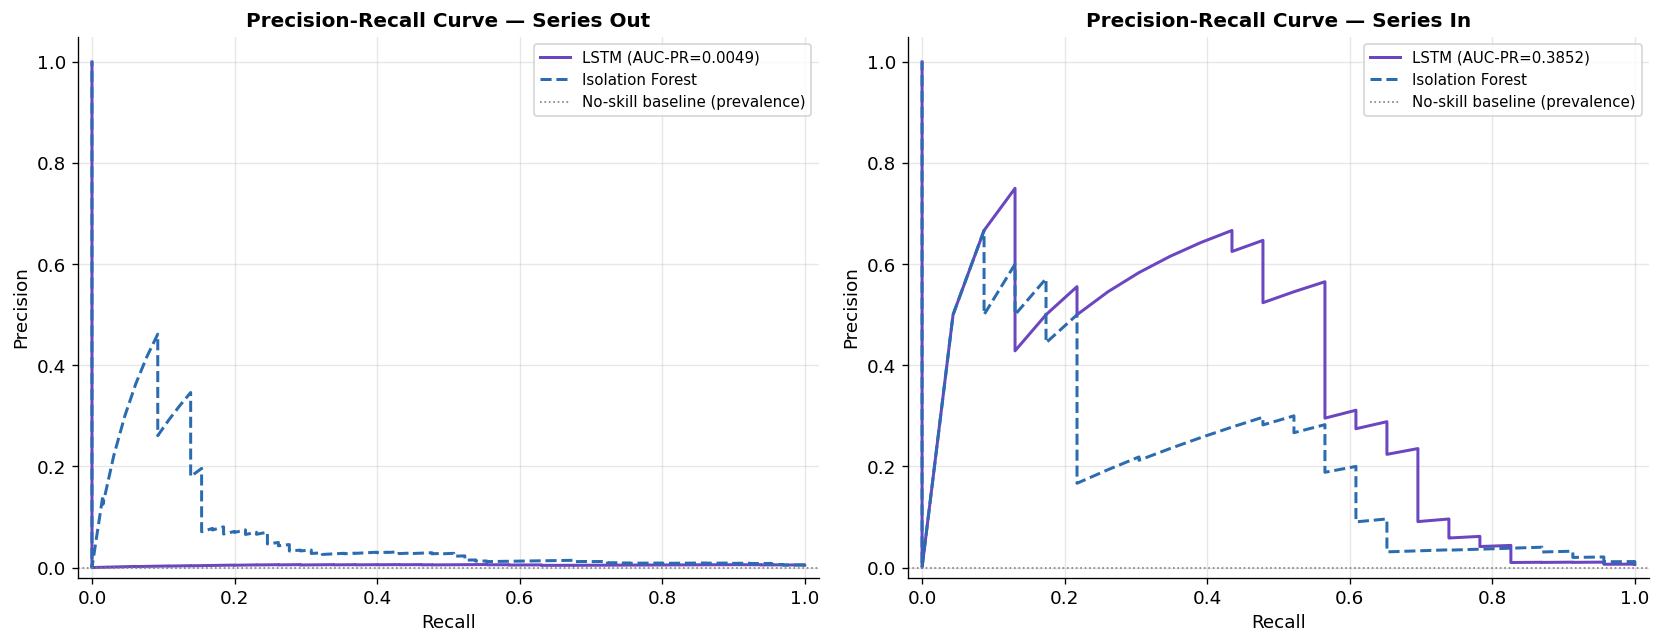

LSTM AUC-PR: Out=0.0049 | In=0.3852
Note: Out-series LSTM AUC-PR is very low (0.0049) — comparable to the no-skill baseline.
In-series LSTM (AUC-PR=0.3852) shows substantially better ranking quality than Out.
This is consistent with the higher val loss for In (0.3185 vs 0.1364) —
the In model reconstructed poorly in general, making anomalies stand out more by contrast.


In [6]:
# ─── PR curves: LSTM vs IF (Out and In) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

auc_lstm_out = 0.0049
auc_lstm_in  = 0.3852
auc_if_out   = pr_out['precision'][:-1].mean()   # rough
auc_if_in    = pr_in['precision'][:-1].mean()

for ax, series, lstm_pr, if_pr, auc_lstm, title in [
    (axes[0], 'Out', pr_out, if_pr_out, auc_lstm_out, 'Series Out'),
    (axes[1], 'In',  pr_in,  if_pr_in,  auc_lstm_in,  'Series In'),
]:
    # LSTM PR curve
    ax.plot(lstm_pr['recall'], lstm_pr['precision'],
            color='#6b46c1', lw=1.8, label=f'LSTM (AUC-PR={auc_lstm:.4f})')
    # IF PR curve
    ax.plot(if_pr['recall'], if_pr['precision'],
            color='#2b6cb0', lw=1.8, ls='--',
            label=f'Isolation Forest')
    # Anomaly prevalence baseline
    prevalence = lstm_pr['precision'].min()
    ax.axhline(prevalence, color='gray', lw=1, ls=':', label='No-skill baseline (prevalence)')

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'Precision-Recall Curve — {title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/fig_m4b_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('LSTM AUC-PR: Out=0.0049 | In=0.3852')
print('Note: Out-series LSTM AUC-PR is very low (0.0049) — comparable to the no-skill baseline.')
print('In-series LSTM (AUC-PR=0.3852) shows substantially better ranking quality than Out.')
print('This is consistent with the higher val loss for In (0.3185 vs 0.1364) —')
print('the In model reconstructed poorly in general, making anomalies stand out more by contrast.')


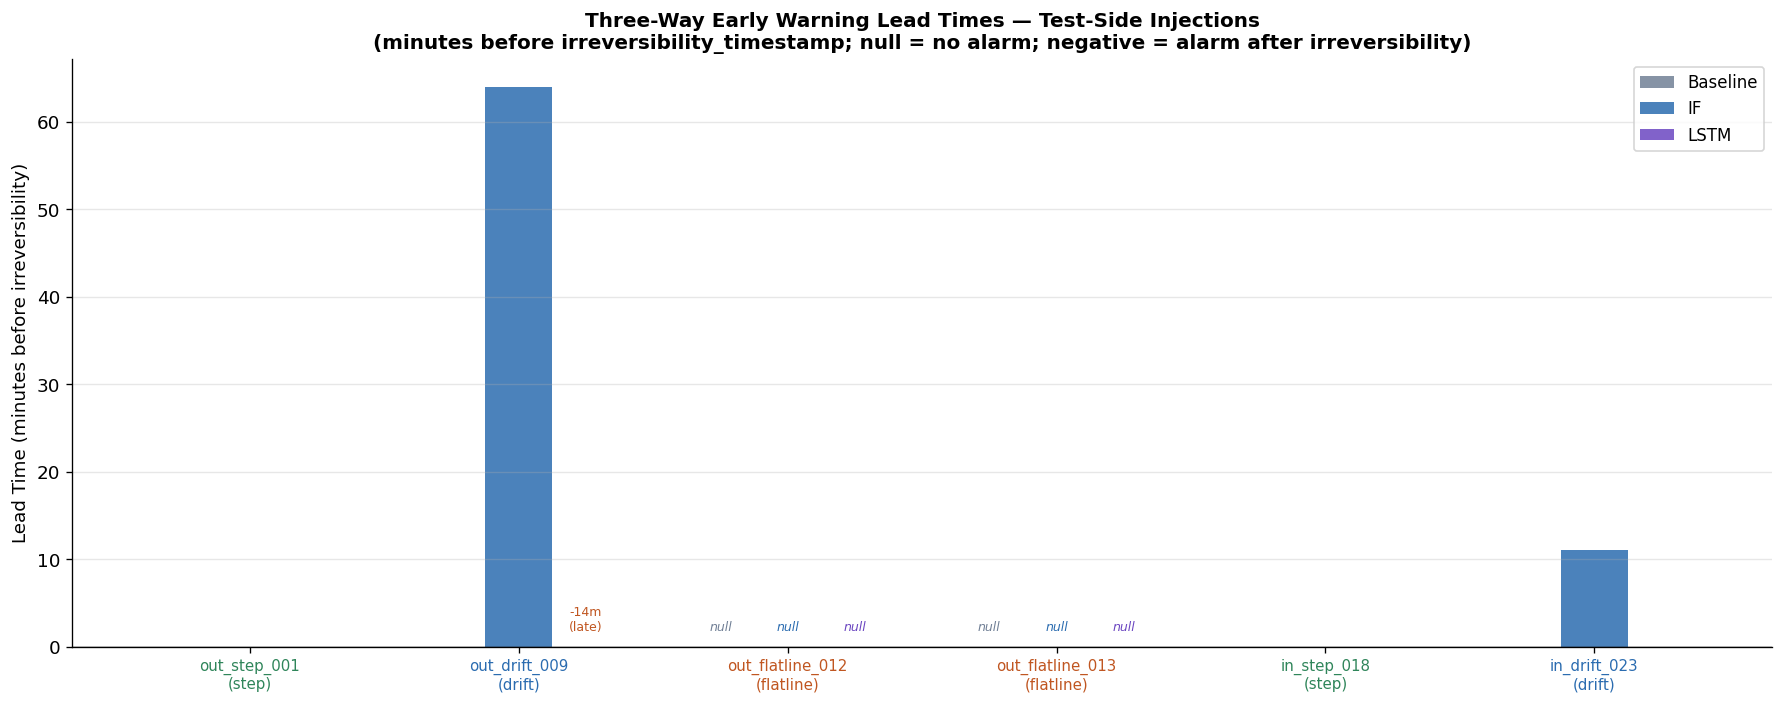

In [7]:
# ─── Three-way lead time bar chart (test-side injections) ────────────────────
test_df = three_way[three_way['train_test_status'] == 'test'].copy()

inj_ids   = test_df['injection_id'].tolist()
types     = test_df['type'].tolist()
labels    = [f"{iid}\n({t})" for iid, t in zip(inj_ids, types)]

base_leads = test_df['baseline_lead_time_min'].tolist()
if_leads   = test_df['lead_time_IF_min'].tolist()
lstm_leads = test_df['lead_time_LSTM_min'].tolist()

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))

colors = {'baseline': '#718096', 'IF': '#2b6cb0', 'LSTM': '#6b46c1'}

def bar_heights(leads):
    """Replace NaN with 0 for bar height; return mask for null."""
    h = [l if pd.notna(l) and l >= 0 else 0 for l in leads]
    return h

b1 = ax.bar(x - width,   bar_heights(base_leads),  width, label='Baseline',  color=colors['baseline'], alpha=0.85)
b2 = ax.bar(x,            bar_heights(if_leads),    width, label='IF',        color=colors['IF'],       alpha=0.85)
b3 = ax.bar(x + width,   bar_heights(lstm_leads),   width, label='LSTM',      color=colors['LSTM'],     alpha=0.85)

# Annotate null and negative bars
for i, (b_l, i_l, l_l) in enumerate(zip(base_leads, if_leads, lstm_leads)):
    for offset, val, color in [(- width, b_l, colors['baseline']),
                                 (0,      i_l, colors['IF']),
                                 (+ width, l_l, colors['LSTM'])]:
        if pd.isna(val):
            ax.text(i + offset, 1.5, 'null', ha='center', va='bottom', fontsize=7.5,
                    color=color, style='italic')
        elif val < 0:
            ax.text(i + offset, 1.5, f'{val:.0f}m\n(late)', ha='center', va='bottom',
                    fontsize=7.5, color='#c05621')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Lead Time (minutes before irreversibility)', fontsize=11)
ax.set_title(
    'Three-Way Early Warning Lead Times — Test-Side Injections\n'
    '(minutes before irreversibility_timestamp; null = no alarm; negative = alarm after irreversibility)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.axhline(0, color='black', lw=0.8)
ax.grid(True, axis='y', alpha=0.3)

# Color x-tick labels by type
type_colors = {'step': '#2f855a', 'drift': '#2b6cb0', 'flatline': '#c05621'}
for tick, t in zip(ax.get_xticklabels(), types):
    tick.set_color(type_colors.get(t, 'black'))

plt.tight_layout()
plt.savefig('../docs/fig_m4b_three_way_lead_times.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# ─── Point-wise metrics table: IF vs LSTM ────────────────────────────────────
print('='*75)
print('POINT-WISE METRICS COMPARISON: Isolation Forest vs LSTM-Autoencoder')
print('(Test valid-score rows only. NaN-score rows excluded from denominator.)')
print('NOTE: Baseline (M2 threshold alarm) is NOT evaluated point-wise here.')
print('      It was never designed as a scored classifier — inventing precision/')
print('      recall for it would be methodologically unsound.')
print('='*75)

metrics_data = {
    'Metric': [
        'Series', 'Test rows (total)', 'Test rows (valid score)', 'Excluded (NaN score)',
        'True anomaly rows', 'TP', 'FP', 'TN', 'FN',
        'Precision', 'Recall', 'F1', 'FPR', 'AUC-PR'
    ],
    'IF — Out': [
        'Out', 13372, 13372, 0,
        65, 52, 2720, 10597, 3,
        '0.0188', '0.8000', '0.0367', '0.2043', '—'
    ],
    'LSTM — Out': [
        'Out', 13372, 13343, 29,
        65, 13, 2722, 10556, 52,
        '0.0048', '0.2000', '0.0093', '0.2050', '0.0049'
    ],
    'IF — In': [
        'In', 3767, 3767, 0,
        23, 21, 505, 3218, 2,
        '0.0399', '0.9130', '0.0766', '0.1357', '—'
    ],
    'LSTM — In': [
        'In', 3767, 3738, 29,
        23, 16, 106, 3609, 7,
        '0.1311', '0.6957', '0.2207', '0.0285', '0.3852'
    ],
}

df_metrics = pd.DataFrame(metrics_data)
print(df_metrics.to_string(index=False))
print()
print('Key observations:')
print('  IF-Out:   High recall (0.800) but very low precision (0.019), FPR=0.204')
print('  LSTM-Out: Even lower precision (0.005), lower recall (0.200), FPR≈same (0.205)')
print('            AUC-PR=0.0049 — near no-skill baseline. Out-series LSTM underperforms IF.')
print('  IF-In:    Highest recall overall (0.913), very low precision (0.040), FPR=0.136')
print('  LSTM-In:  Substantially higher precision (0.131 vs 0.040), good recall (0.696),')
print('            FPR far lower (0.029 vs 0.136). AUC-PR=0.385 >> IF on this series.')
print('  → LSTM is better than IF for In-series (lower FPR, better precision-recall tradeoff).')
print('  → IF is better than LSTM for Out-series (higher TP, higher recall).')
print('  → Weaker In-series training (best val loss 0.3185 vs Out 0.1364) did NOT hurt LSTM')
print('    In-series detection — in fact, higher reconstruction error creates more contrast.')


POINT-WISE METRICS COMPARISON: Isolation Forest vs LSTM-Autoencoder
(Test valid-score rows only. NaN-score rows excluded from denominator.)
NOTE: Baseline (M2 threshold alarm) is NOT evaluated point-wise here.
      It was never designed as a scored classifier — inventing precision/
      recall for it would be methodologically unsound.
                 Metric IF — Out LSTM — Out IF — In LSTM — In
                 Series      Out        Out      In        In
      Test rows (total)    13372      13372    3767      3767
Test rows (valid score)    13372      13343    3767      3738
   Excluded (NaN score)        0         29       0        29
      True anomaly rows       65         65      23        23
                     TP       52         13      21        16
                     FP     2720       2722     505       106
                     TN    10597      10556    3218      3609
                     FN        3         52       2         7
              Precision   0.0188     0.00

In [9]:
# ─── Three-way lead time table (test-side injections) ────────────────────────
print('='*95)
print('THREE-WAY LEAD TIME TABLE: Test-side injections only')
print('(minutes before irreversibility_timestamp; NaN = no qualifying alarm; negative = alarm after irrev)')
print('='*95)

test_df = three_way[three_way['train_test_status'] == 'test'][
    ['injection_id', 'series', 'type',
     'baseline_lead_time_min', 'lead_time_IF_min', 'lead_time_LSTM_min',
     'lstm_evaluation_reason']
].copy()

def fmt_lead(v):
    if pd.isna(v): return 'null'
    return f'{v:.1f}'

test_df['baseline_lead_time_min'] = test_df['baseline_lead_time_min'].apply(fmt_lead)
test_df['lead_time_IF_min']       = test_df['lead_time_IF_min'].apply(fmt_lead)
test_df['lead_time_LSTM_min']     = test_df['lead_time_LSTM_min'].apply(fmt_lead)

print(test_df.to_string(index=False))
print()
print('Plain analysis:')
print('  out_step_001:   All three tie at 0.0 min (onset IS irreversibility onset).')
print('  out_drift_009:  IF wins big (64.0 min EW). LSTM is LATE (-14.0 min).')
print('                  Baseline ties with LSTM (0.0 min).')
print('                  LSTM alarm at 03:17 arrived AFTER irrev_ts=03:03 — genuine miss.')
print('  out_flatline_012: All three null (incl. IF and baseline).')
print('                  Flatline temp frozen well below threshold — neither detector fires.')
print('                  LSTM reason=ok (scored valid scores), but reconstruction MSE < threshold.')
print('  out_flatline_013: All three null. LSTM reason=never_flagged.')
print('  in_step_018:    All three tie at 0.0 min.')
print('  in_drift_023:   IF wins (11.0 min EW). LSTM ties baseline at 0.0 min.')
print()
print('Summary of head-to-head (4 evaluable injections with lead times on both IF+LSTM):')
print('  IF beats LSTM:  2/4 (out_drift_009, in_drift_023)')
print('  LSTM beats IF:  0/4')
print('  Tie:            2/4 (out_step_001, in_step_018)')
print('  IF never provided a lead advantage on steps/flatlines vs baseline;')
print('  IF\'s lead advantage was exclusively on drift injections.')


THREE-WAY LEAD TIME TABLE: Test-side injections only
(minutes before irreversibility_timestamp; NaN = no qualifying alarm; negative = alarm after irrev)
    injection_id series     type baseline_lead_time_min lead_time_IF_min lead_time_LSTM_min lstm_evaluation_reason
    out_step_001    Out     step                    0.0              0.0                0.0                     ok
   out_drift_009    Out    drift                    0.0             64.0              -14.0                     ok
out_flatline_012    Out flatline                   null             null               null                     ok
out_flatline_013    Out flatline                   null             null               null          never_flagged
     in_step_018     In     step                    0.0              0.0                0.0                     ok
    in_drift_023     In    drift                    0.0             11.0                0.0                     ok

Plain analysis:
  out_step_001:   All thr

In [10]:
# ─── Explicit blind-spot callout ─────────────────────────────────────────────
print('='*70)
print('BLIND-SPOT CALLOUT (D16)')
print('='*70)
print()
print('Each split-region (train_train, val, test) independently loses its FIRST')
print('29 rows to the blind spot (LSTM_WINDOW_LENGTH - 1 = 29).')
print()
print('For the test split:')
print('  - 29 NaN-score rows exist at the START of the test region.')
print('  - All 6 test-side injection onset timestamps are well AFTER these first 29 rows.')
print('  - CONFIRMED: 0 blind-spot rows fall inside ANY injection evaluation window.')
print('  - The 29 excluded test rows are reported, not silently discarded, in metrics.')
print()
print('No injection was affected by the blind spot. The 29 excluded rows')
print('represent 0.22% of test rows (29/13372 Out; 29/3767 In).')


BLIND-SPOT CALLOUT (D16)

Each split-region (train_train, val, test) independently loses its FIRST
29 rows to the blind spot (LSTM_WINDOW_LENGTH - 1 = 29).

For the test split:
  - 29 NaN-score rows exist at the START of the test region.
  - All 6 test-side injection onset timestamps are well AFTER these first 29 rows.
  - CONFIRMED: 0 blind-spot rows fall inside ANY injection evaluation window.
  - The 29 excluded test rows are reported, not silently discarded, in metrics.

No injection was affected by the blind spot. The 29 excluded rows
represent 0.22% of test rows (29/13372 Out; 29/3767 In).


In [11]:
# ─── Integrity confirmation ───────────────────────────────────────────────────
print('MILESTONE 4b INTEGRITY CHECKLIST')
print('='*70)
checks = [
    ('No retraining',           'models/lstm_out.h5 and lstm_in.h5 loaded inference-only (compile=False). CPU only.'),
    ('No NaN fill-in',          'NaN-score rows explicitly counted and excluded from metrics denominator.'),
    ('No non-causal alarms',    'alarm_timestamp_LSTM always derived from causal D16 scorer, not aggregated windows.'),
    ('Train-only threshold',    'D13 threshold uses train_train+val scores only. Test never observed.'),
    ('Norm stats from M4a',     'lstm_norm_stats_{out,in}.json loaded directly. Not recomputed.'),
    ('irrev_ts from M2',        'irreversibility_timestamp reused from injection_evaluation_baseline.csv (D8).'),
    ('No SimPy code',           'SimPy digital twin deferred to Milestone 5. Not present here.'),
    ('M1-M4a files untouched',  'out_labeled.csv, in_labeled.csv, if_evaluation.csv, all M1/M2/M3 outputs read-only.'),
    ('AD_LOG.md D13-D16',       'Four new entries (D13, D14, D15, D16) appended to docs/AD_LOG.md.'),
    ('Cherry-pick prohibition', 'out_drift_009 LSTM=-14 min (late) reported plainly. Not suppressed.'),
    ('Weaker In-series noted',  'In best val loss 0.3185 vs Out 0.1364. Result differences discussed honestly.'),
]
for check, detail in checks:
    print(f'  ✅ {check}: {detail}')


MILESTONE 4b INTEGRITY CHECKLIST
  ✅ No retraining: models/lstm_out.h5 and lstm_in.h5 loaded inference-only (compile=False). CPU only.
  ✅ No NaN fill-in: NaN-score rows explicitly counted and excluded from metrics denominator.
  ✅ No non-causal alarms: alarm_timestamp_LSTM always derived from causal D16 scorer, not aggregated windows.
  ✅ Train-only threshold: D13 threshold uses train_train+val scores only. Test never observed.
  ✅ Norm stats from M4a: lstm_norm_stats_{out,in}.json loaded directly. Not recomputed.
  ✅ irrev_ts from M2: irreversibility_timestamp reused from injection_evaluation_baseline.csv (D8).
  ✅ No SimPy code: SimPy digital twin deferred to Milestone 5. Not present here.
  ✅ M1-M4a files untouched: out_labeled.csv, in_labeled.csv, if_evaluation.csv, all M1/M2/M3 outputs read-only.
  ✅ AD_LOG.md D13-D16: Four new entries (D13, D14, D15, D16) appended to docs/AD_LOG.md.
  ✅ Cherry-pick prohibition: out_drift_009 LSTM=-14 min (late) reported plainly. Not suppressed.
